## Q1. Load the bank.csv dataset into a Spark DataFrame. Perform basic data inspection tasks such as showing the first few rows, printing the schema, and displaying a summary of numerical columns.

In [1]:
#Import required library

from pyspark.sql import SparkSession

In [2]:
## Create Spark session

spark = SparkSession.builder.appName("BankDataProcessing").getOrCreate()

In [3]:
# Load dataset
bank_df = spark.read.csv(
"/content/drive/MyDrive/capstone project /ml engineer/Banking_Distributed_ML_Project/bank.csv",
header=True,
inferSchema=True
)

In [4]:
#Display sample records
bank_df.show(5)

+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown|  5|  may|     22

In [5]:
#Display schema

bank_df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [6]:
#Generate summary statistics
bank_df.describe().show()

+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|summary|               age|    job| marital|education|default|           balance|housing|loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|   y|
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|  count|              4521|   4521|    4521|     4521|   4521|              4521|   4521|4521|    4521|              4521| 4521|              4521|              4521|              4521|              4521|    4521|4521|
|   mean| 41.17009511170095|   NULL|    NULL|     NULL|   NULL|1422.6578190665782|   NULL|NULL|    NULL|15.9152842291528

**Conclusion**

The dataset was successfully loaded into a Spark DataFrame.
Sample records confirmed that the file was read correctly,
while schema inspection verified the detected data types.
Summary statistics provided a quick overview of customer
demographics, balances, and campaign-related attributes,
preparing the data for further analysis.

###  Q2. Filter the dataset to include only clients with a balance greater than a certain threshold (e.g., 1000). Extract the month from the 'month' column and create a new column for the quarter of the year.

In [7]:
from pyspark.sql.functions import col, when

In [8]:
#Select customers with balance above 1000

high_balance_df = bank_df.where(col("balance") > 1000)

In [9]:
### Create quarter column

quarterly_df = high_balance_df.withColumn(
"quarter",
when(col("month").isin("jan", "feb", "mar"), "Q1")
.when(col("month").isin("apr", "may", "jun"), "Q2")
.when(col("month").isin("jul", "aug", "sep"), "Q3")
.when(col("month").isin("oct", "nov", "dec"), "Q4")
.otherwise("Unknown")
)

In [10]:
### View records

quarterly_df.show(5)

+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+-------+
|age|       job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|quarter|
+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+-------+
| 30|unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|     Q4|
| 33|  services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|     Q2|
| 35|management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|     Q2|
| 30|management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|     Q2|
| 39|  services|married|secondary|     no

In [11]:
## Check quarter mapping
quarterly_df.select("month", "quarter").distinct().show()

+-----+-------+
|month|quarter|
+-----+-------+
|  jul|     Q3|
|  nov|     Q4|
|  aug|     Q3|
|  feb|     Q1|
|  oct|     Q4|
|  sep|     Q3|
|  may|     Q2|
|  dec|     Q4|
|  jun|     Q2|
|  jan|     Q1|
|  apr|     Q2|
|  mar|     Q1|
+-----+-------+



### Conclusion
Customers with balances greater than 1000 were filtered
from the dataset. A new quarter field was also created
from the month column, enabling seasonal and quarterly
trend analysis. This transformation simplifies reporting
and helps identify patterns over broader time periods.

## Q3. Group the data by job type and calculate the average balance and median age for each job category. Find the total number of clients for each marital status who have subscribed to a term deposit.

In [12]:
from pyspark.sql.functions import avg, count, percentile_approx

In [13]:
## Job-wise statistics

occupation_stats = quarterly_df.groupBy("job").agg(
avg("balance").alias("average_balance"),
percentile_approx("age", 0.5).alias("median_age")
)

occupation_stats.show(truncate=False)

+-------------+------------------+----------+
|job          |average_balance   |median_age|
+-------------+------------------+----------+
|management   |4229.221621621622 |39        |
|retired      |5290.106382978724 |59        |
|unknown      |3294.6            |44        |
|self-employed|3623.7903225806454|41        |
|student      |3794.8064516129034|25        |
|blue-collar  |3143.5575539568345|41        |
|entrepreneur |4851.423076923077 |40        |
|admin.       |3342.1710526315787|41        |
|technician   |3768.2928870292885|38        |
|services     |3529.6724137931033|40        |
|housemaid    |6592.242424242424 |46        |
|unemployed   |3017.8205128205127|43        |
+-------------+------------------+----------+



In [14]:
## Subscription count by marital status
marital_summary = quarterly_df.filter(col("y") == "yes").groupBy("marital").agg(count("*").alias("subscription_count"))

marital_summary.show()

+--------+------------------+
| marital|subscription_count|
+--------+------------------+
|divorced|                29|
| married|               128|
|  single|                64|
+--------+------------------+



### Conclusion
Analysis by occupation revealed variations in average
account balances and age distributions across job categories.
Retired and housemaid customers showed relatively higher
balances. Subscription analysis indicated that married
customers accounted for the largest share of successful
term deposit subscriptions.

## Q4. Write a UDF that categorizes clients into age groups (<30, 30-60, >60) and apply it to create a new column age_group.

In [15]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

In [16]:
#Define age grouping function

def classify_age(age):
  if age < 30:
    return "<30"
  elif age <= 60:
    return "30-60"
  else:
    return ">60"

In [17]:
## Register UDF

age_category_udf = udf(classify_age, StringType())

In [18]:
## Apply UDF
age_df = quarterly_df.withColumn(
"age_group",
age_category_udf(col("age"))
)

In [19]:
## Display results
age_df.select("age", "age_group").distinct().orderBy("age").show(10)

+---+---------+
|age|age_group|
+---+---------+
| 19|      <30|
| 20|      <30|
| 21|      <30|
| 22|      <30|
| 23|      <30|
| 24|      <30|
| 25|      <30|
| 26|      <30|
| 27|      <30|
| 28|      <30|
+---+---------+
only showing top 10 rows


**Conclusion**

A user-defined function was used to classify customers
into three age categories. The newly created age_group
column improves customer segmentation and supports
demographic-based analysis and reporting.

## Q5. Calculate the subscription rate (percentage of clients who subscribed to a term deposit) for each education level. Identify the top 3 professions that have the highest loan default rate.

In [20]:
from pyspark.sql.functions import round

In [21]:
## Total customers by education
education_total = age_df.groupBy("education").agg(count("*").alias("total_customers"))

In [22]:
## Subscribers by education
education_yes = age_df.filter(col("y") == "yes").groupBy("education").agg(count("*").alias("subscribers"))

In [23]:
## Calculate subscription percentage
education_rate = education_total.join(
education_yes,
on="education",
how="left"
).fillna(0).withColumn(
"subscription_rate",
round((col("subscribers") / col("total_customers")) * 100, 2)
)

education_rate.select(
"education",
"subscription_rate"
).show()

+---------+-----------------+
|education|subscription_rate|
+---------+-----------------+
|  unknown|            17.65|
| tertiary|             17.9|
|secondary|            13.39|
|  primary|            11.79|
+---------+-----------------+



In [24]:
## Default rate by profession
profession_total = age_df.groupBy("job").agg(count("*").alias("total_clients"))

profession_default = age_df.filter(col("loan") == "yes").groupBy("job").agg(count("*").alias("loan_clients"))

profession_rate = profession_total.join(
profession_default,
on="job",
how="left"
).fillna(0).withColumn(
"loan_rate",
round((col("loan_clients") / col("total_clients")) * 100, 2)
)

profession_rate.orderBy(
col("loan_rate").desc()
).limit(3).select(
"job",
"loan_rate"
).show()

+-------------+---------+
|          job|loan_rate|
+-------------+---------+
| entrepreneur|    28.85|
|self-employed|     12.9|
|      retired|    12.77|
+-------------+---------+



**Conclusion**

Subscription rates differed across education groups,
with tertiary and unknown education categories showing
stronger participation levels. The profession analysis
highlighted occupations with a larger proportion of
customers holding loans, which may be useful for
financial risk assessment and customer profiling.

## Q6. Concatenate the 'job' and 'marital' columns into a new column 'job_marital'. Use string functions to convert the 'contact' column to uppercase.

In [25]:
from pyspark.sql.functions import concat_ws, upper

In [26]:
## Combine job and marital columns
combined_df = age_df.withColumn(
"job_marital",
concat_ws("-", col("job"), col("marital"))
)

In [27]:
## Convert contact values to uppercase
formatted_df = combined_df.withColumn(
"contact_upper",
upper(col("contact"))
)

In [28]:
## Display transformed columns
formatted_df.select(
"job",
"marital",
"job_marital",
"contact",
"contact_upper"
).show(5)

+----------+-------+------------------+--------+-------------+
|       job|marital|       job_marital| contact|contact_upper|
+----------+-------+------------------+--------+-------------+
|unemployed|married|unemployed-married|cellular|     CELLULAR|
|  services|married|  services-married|cellular|     CELLULAR|
|management| single| management-single|cellular|     CELLULAR|
|management|married|management-married| unknown|      UNKNOWN|
|  services|married|  services-married| unknown|      UNKNOWN|
+----------+-------+------------------+--------+-------------+
only showing top 5 rows


**Conclusion**

The job and marital status columns were merged to create
a new descriptive feature, while contact values were
standardized using uppercase formatting. These operations
improve data consistency and can support reporting,
grouping, and feature engineering tasks.

## Q7. Convert the Spark DataFrame to a Pandas DataFrame. Create a bar plot showing the count of clients by job type.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
# Convert grouped Spark DataFrame to Pandas
job_distribution = formatted_df.groupBy("job").count().toPandas()
job_distribution.head()

,job,count
0,management,370
1,retired,94
2,unknown,15
3,self-employed,62
4,student,31


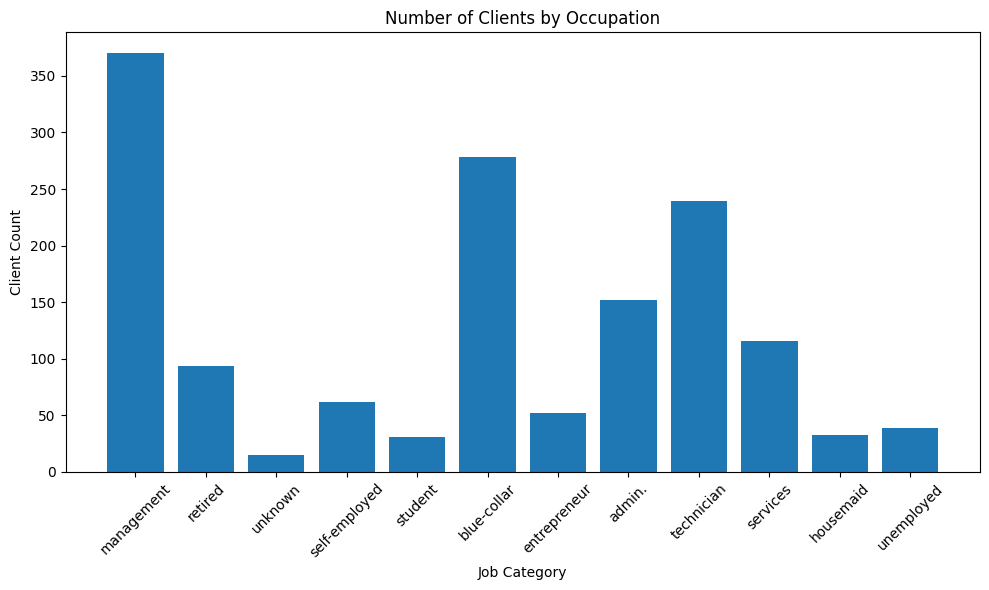

In [32]:
plt.figure(figsize=(10,6))
plt.bar(job_distribution["job"], job_distribution["count"])
plt.xticks(rotation=45)
plt.title("Number of Clients by Occupation")
plt.xlabel("Job Category")
plt.ylabel("Client Count")
plt.tight_layout()
plt.show()

**Conclusion**

The visualization provides a clear picture of customer
distribution across different occupations. Certain job
categories such as management, blue-collar, and technician
represent a large portion of the customer base, making them
important segments for marketing and customer engagement
strategies.

## Q8. Analyze which month of the year has the highest number of clients contacted, and determine the success rate of the campaign in that month.

In [33]:
from pyspark.sql.functions import count, round, col

In [36]:
#Total contacts per month
monthly_contact_count = formatted_df.groupBy("month").agg(count("*").alias("contacts"))

DataFrame[month: string, contacts: bigint]

In [37]:
# Successful subscriptions per month
monthly_success_count = formatted_df.filter(col("y") == "yes").groupBy("month").agg(count("*").alias("successful"))

In [38]:
# Merge results and calculate success rate
campaign_summary = monthly_contact_count.join(
monthly_success_count,
on="month",
how="left"
).fillna(0).withColumn(
"success_rate",round((col("successful") / col("contacts")) * 100, 2)).orderBy(col("contacts").desc())

campaign_summary.show()

+-----+--------+----------+------------+
|month|contacts|successful|success_rate|
+-----+--------+----------+------------+
|  may|     384|        33|        8.59|
|  jun|     224|        29|       12.95|
|  nov|     207|        26|       12.56|
|  aug|     195|        34|       17.44|
|  jul|     154|        15|        9.74|
|  apr|     118|        22|       18.64|
|  feb|      76|        21|       27.63|
|  jan|      36|         9|        25.0|
|  oct|      33|        12|       36.36|
|  mar|      24|         9|        37.5|
|  sep|      18|         7|       38.89|
|  dec|      12|         4|       33.33|
+-----+--------+----------+------------+



**Conclusion**

The monthly campaign analysis identifies periods with
the highest customer outreach activity and measures the
effectiveness of those campaigns. While some months have
a larger number of contacts, others achieve higher
conversion rates, offering valuable insight for future
campaign planning.

## Q9. Find the average duration of contact for clients who subscribed (y = yes) versus those who did not (y = no).

In [39]:
from pyspark.sql.functions import mean

In [40]:
# Calculate average duration based on subscription outcome

duration_analysis = formatted_df.groupBy("y").agg(
round(mean("duration"), 2).alias("average_duration")
)

duration_analysis.show()

+---+----------------+
|  y|average_duration|
+---+----------------+
| no|          232.76|
|yes|          484.34|
+---+----------------+



**Conclusion**

Customers who subscribed to a term deposit generally
experienced longer conversations compared to those who
did not subscribe. This suggests that engagement duration
may play a role in influencing customer decisions during
marketing interactions.

Q10. Calculate the correlation coefficient between 'age' and 'balance' to see if there’s any linear relationship between these two variables.

In [41]:
import builtins

## Compute correlation coefficient

In [42]:
age_balance_corr = bank_df.stat.corr("age", "balance")

print(
"Correlation between age and balance:",
builtins.round(age_balance_corr, 4)
)

Correlation between age and balance: 0.0838


**Conclusion**

The calculated correlation coefficient indicates a very
weak positive relationship between age and account balance.
Although older customers may tend to have slightly larger
balances, age alone is not a strong factor in explaining
balance variations within this dataset.

## Q11. Analyze the proportion of clients with and without a credit default and visualize the count of defaulters and non-defaulters.

In [43]:
import matplotlib.pyplot as plt

In [44]:
#Count default categories

default_summary = formatted_df.groupBy("default").count().toPandas()

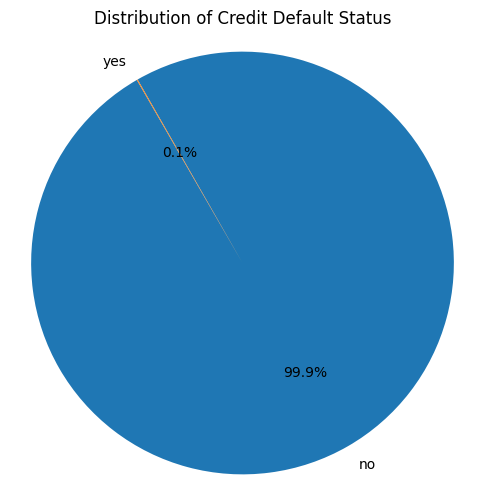

In [45]:
# Create pie chart

plt.figure(figsize=(6,6))
plt.pie(
default_summary["count"],
labels=default_summary["default"],
autopct="%1.1f%%",
startangle=120
)

plt.title("Distribution of Credit Default Status")
plt.axis("equal")
plt.show()

In [46]:
# Display counts

default_summary

,default,count
0,no,1480
1,yes,1


**Conclusion**

The analysis shows that only a very small proportion of
customers have a recorded credit default. Most customers
fall into the non-default category, indicating a generally
low-risk customer population within the dataset.

## Q12. Investigate which contact method ('cellular', 'telephone', etc.) has the highest success rate for term deposit subscriptions.

In [48]:
# Total contacts by method

contact_totals = formatted_df.groupBy("contact").agg(count("*").alias("total_contacts"))

In [51]:
# Successful subscriptions by method
contact_success = formatted_df.filter(col("y") == "yes").groupBy("contact").agg(count("*").alias("successful_contacts"))


In [52]:
# Calculate success percentage
contact_performance = contact_totals.join(
contact_success,
on="contact",
how="left"
).fillna(0).withColumn(
"success_rate",
round(
(col("successful_contacts") / col("total_contacts")) * 100,
2
)
).orderBy(col("success_rate").desc())

contact_performance.show()

+---------+--------------+-------------------+------------+
|  contact|total_contacts|successful_contacts|success_rate|
+---------+--------------+-------------------+------------+
|telephone|           120|                 26|       21.67|
| cellular|           946|                171|       18.08|
|  unknown|           415|                 24|        5.78|
+---------+--------------+-------------------+------------+



**Conclusion**

Comparing communication channels revealed differences
in campaign effectiveness. Telephone and cellular contacts
achieved higher success rates than unknown contact methods,
highlighting the importance of selecting appropriate
communication channels for customer outreach.

## Q13. Calculate the average account balance for different age groups or the most common job types. (Use CREATE TEMPORARY VIEW in Spark SQL to query data using SQL syntax.)

In [53]:
# Register temporary SQL view
formatted_df.createOrReplaceTempView("customer_bank_data")

In [54]:
# Average balance by age group
spark.sql("""
SELECT
age_group,
ROUND(AVG(balance),2) AS average_balance
FROM customer_bank_data
GROUP BY age_group
ORDER BY age_group
""").show()

+---------+---------------+
|age_group|average_balance|
+---------+---------------+
|    30-60|        3853.56|
|      <30|        3488.91|
|      >60|        4993.55|
+---------+---------------+



In [55]:
#Most common occupations

spark.sql("""
SELECT
job,
COUNT(*) AS total_clients
FROM customer_bank_data
GROUP BY job
ORDER BY total_clients DESC
LIMIT 5
""").show()

+-----------+-------------+
|        job|total_clients|
+-----------+-------------+
| management|          370|
|blue-collar|          278|
| technician|          239|
|     admin.|          152|
|   services|          116|
+-----------+-------------+



**Conclusion**

Spark SQL was used to perform analytical queries on the
processed dataset. The results indicate that customers
above 60 years of age maintain higher average balances,
while management and blue-collar occupations represent
the largest customer segments. These insights can assist
banks in designing targeted products and marketing
strategies for specific customer groups.